<a href="https://colab.research.google.com/github/Vishnupriya16102004/gait-analysis-ioht-ml/blob/main/Gait_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FINAL CODE**

In [ ]:
# Downgrade numpy to a version that still supports np.bool (pre‑1.24)
!pip install numpy==1.23.5

# Upgrade other necessary packages
!pip install --upgrade gspread google-auth google-auth-oauthlib google-auth-httplib2 matplotlib scikit-learn


  Using cached gspread-6.2.0-py3-none-any.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: gspread
    Found existing installation: gspread 6.1.4
    Uninstalling gspread-6.1.4:
      Successfully uninstalled gspread-6.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.20.1 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
bigframes 1.38.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.


In [ ]:
from google.colab import auth
auth.authenticate_user()


<ipython-input-3-d66ba33c0f20>:29: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['Timestamp'] = pd.date_range(start=datetime.datetime.now(), periods=len(df), freq='S')


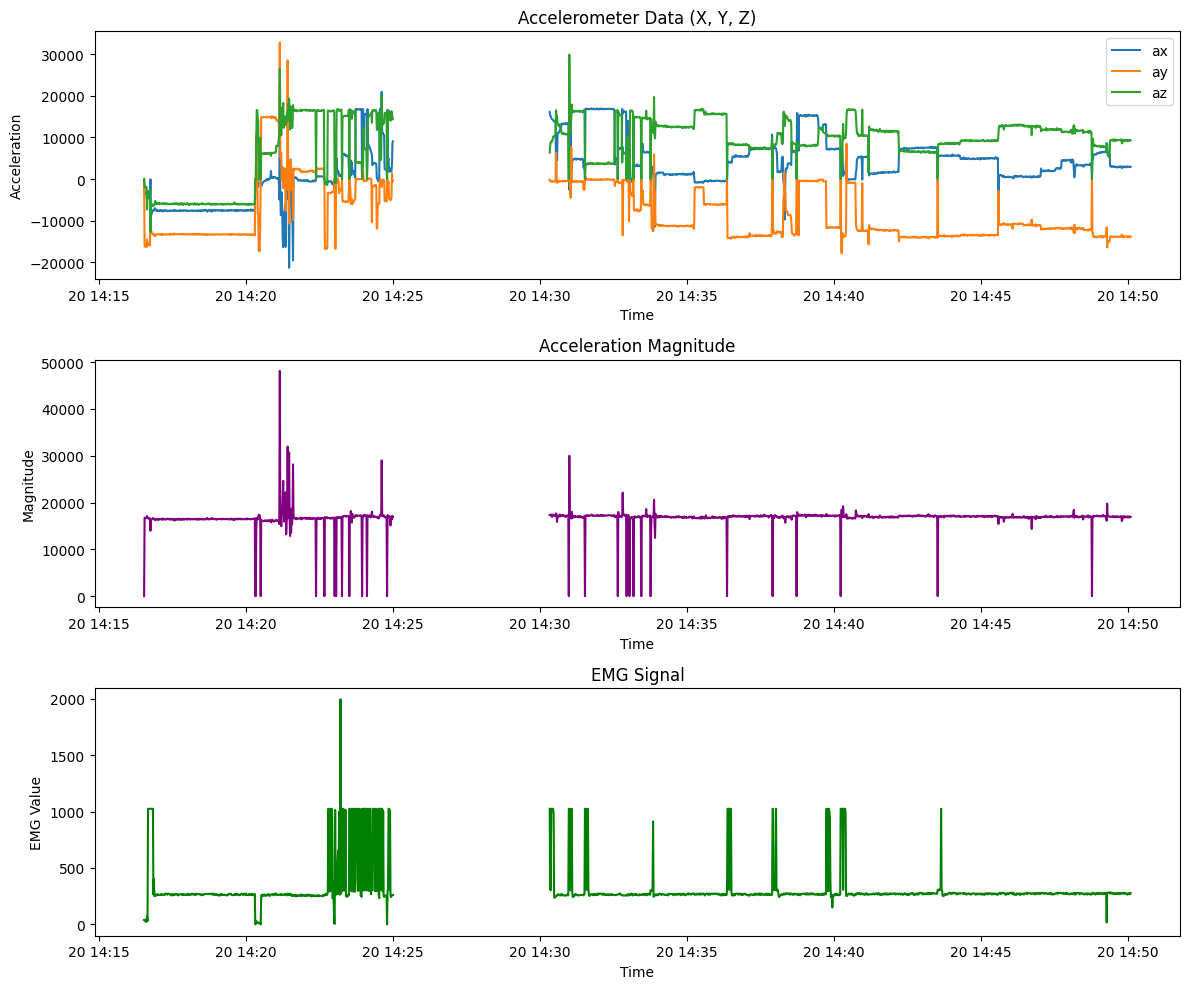

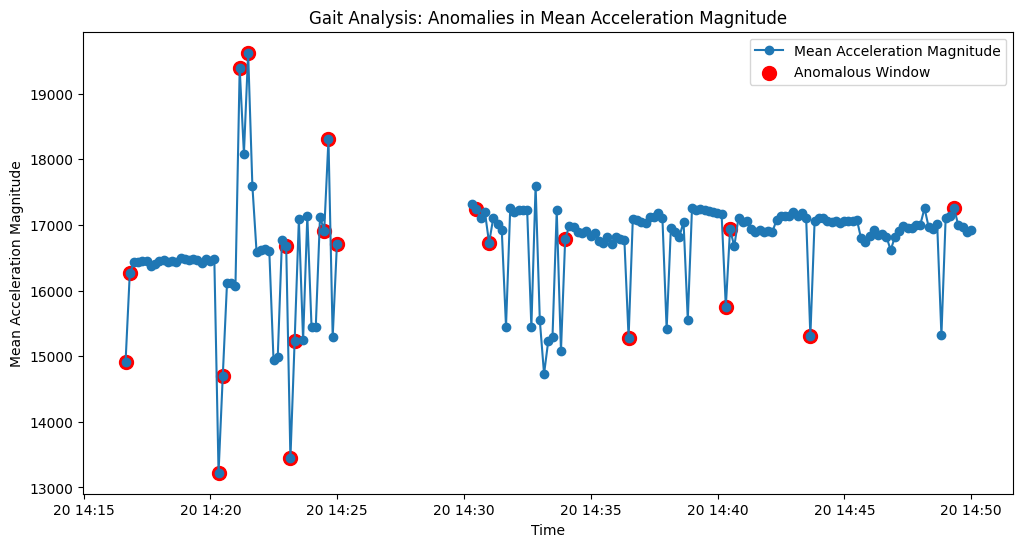

Anomaly Ratio: 0.09950248756218906
Prediction: Gait analysis appears normal. Low risk of muscle injury.


In [ ]:
# Import necessary libraries
import numpy as np
import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import datetime

# -----------------------------
# STEP 1: Authenticate and Fetch Data from Google Sheets
# -----------------------------
# Authenticate and initialize gspread
creds, _ = default()
gc = gspread.authorize(creds)

# Replace with your actual Google Sheet ID (get it from the URL)
spreadsheet_id = "13cLuyUqz8E5Rp9dOkoJpem7Y4dTJbXyFwr8fLxH-ojE"
worksheet = gc.open_by_key(spreadsheet_id).sheet1

# Fetch all records and convert them to a DataFrame
data = worksheet.get_all_records()
df = pd.DataFrame(data)

# Handle timestamps
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
else:
    df['Timestamp'] = pd.date_range(start=datetime.datetime.now(), periods=len(df), freq='S')

# Convert sensor data to numeric
for col in ['ax', 'ay', 'az', 'emg', 'event']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute acceleration magnitude
df['acc_magnitude'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

# -----------------------------
# STEP 2: Visualize Waveforms
# -----------------------------
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(df['Timestamp'], df['ax'], label='ax')
plt.plot(df['Timestamp'], df['ay'], label='ay')
plt.plot(df['Timestamp'], df['az'], label='az')
plt.title('Accelerometer Data (X, Y, Z)')
plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['Timestamp'], df['acc_magnitude'], color='purple')
plt.title('Acceleration Magnitude')
plt.xlabel('Time')
plt.ylabel('Magnitude')

plt.subplot(3, 1, 3)
plt.plot(df['Timestamp'], df['emg'], color='green')
plt.title('EMG Signal')
plt.xlabel('Time')
plt.ylabel('EMG Value')

plt.tight_layout()
plt.show()

# -----------------------------
# STEP 3: Window-Based Feature Extraction & Anomaly Detection
# -----------------------------
window_size = 10
features = []
window_times = []

for i in range(0, len(df) - window_size + 1, window_size):
    window = df.iloc[i:i+window_size]
    mean_acc = window['acc_magnitude'].mean()
    std_acc = window['acc_magnitude'].std()
    mean_emg = window['emg'].mean()
    std_emg = window['emg'].std()
    features.append([mean_acc, std_acc, mean_emg, std_emg])
    window_times.append(window['Timestamp'].iloc[-1])

features = np.array(features)

# Apply IsolationForest for anomaly detection
model = IsolationForest(contamination=0.1, random_state=42)
anomaly_labels = model.fit_predict(features)

df_windows = pd.DataFrame(features, columns=['mean_acc', 'std_acc', 'mean_emg', 'std_emg'])
df_windows['Timestamp'] = window_times
df_windows['anomaly'] = anomaly_labels

# -----------------------------
# STEP 4: Visualization of Anomalies
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df_windows['Timestamp'], df_windows['mean_acc'], label='Mean Acceleration Magnitude', marker='o')
anomalies = df_windows[df_windows['anomaly'] == -1]
plt.scatter(anomalies['Timestamp'], anomalies['mean_acc'], color='red', label='Anomalous Window', s=100)
plt.title('Gait Analysis: Anomalies in Mean Acceleration Magnitude')
plt.xlabel('Time')
plt.ylabel('Mean Acceleration Magnitude')
plt.legend()
plt.show()

# -----------------------------
# STEP 5: Early Injury Prediction
# -----------------------------
anomaly_ratio = np.sum(anomaly_labels == -1) / len(anomaly_labels)
risk_threshold = 0.2

if anomaly_ratio > risk_threshold:
    prediction_text = ("High risk of muscle injury detected! Anomalous gait patterns detected. "
                       "Take preventive action and consult a sports specialist.")
else:
    prediction_text = "Gait analysis appears normal. Low risk of muscle injury."

print("Anomaly Ratio:", anomaly_ratio)
print("Prediction:", prediction_text)


<ipython-input-7-c8dff15a5bd7>:25: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['Timestamp'] = pd.date_range(start=datetime.datetime.now(), periods=len(df), freq='S')


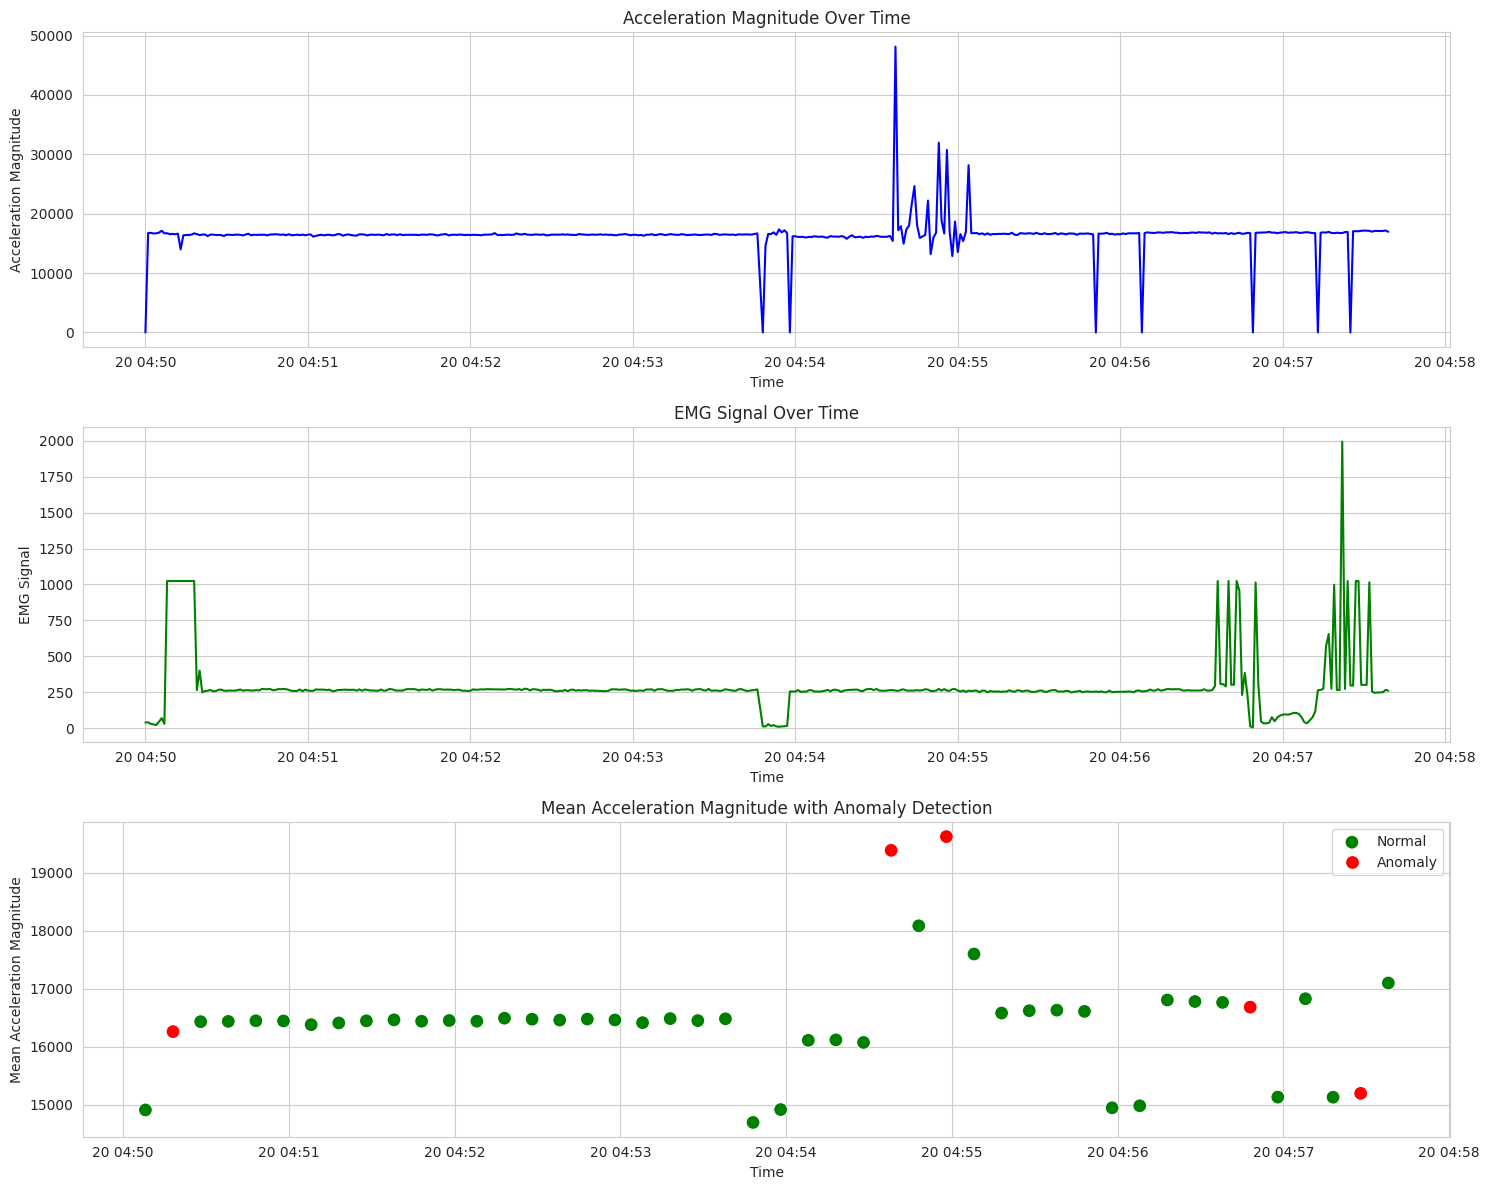

In [ ]:
   # Import libraries
import gspread
from google.auth import default
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import datetime
from IPython.display import display, HTML

# Authenticate & fetch data from Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)
spreadsheet_id = "13cLuyUqz8E5Rp9dOkoJpem7Y4dTJbXyFwr8fLxH-ojE"
worksheet = gc.open_by_key(spreadsheet_id).sheet1

data = worksheet.get_all_records()
df = pd.DataFrame(data)

# Handling timestamp and data conversions
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
else:
    df['Timestamp'] = pd.date_range(start=datetime.datetime.now(), periods=len(df), freq='S')

for col in ['ax', 'ay', 'az', 'emg', 'event']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute acceleration magnitude
df['acc_magnitude'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

# Window-Based Feature Extraction
window_size = 10
features, window_times = [], []

for i in range(0, len(df) - window_size + 1, window_size):
    window = df.iloc[i:i+window_size]
    features.append([
        window['acc_magnitude'].mean(),
        window['acc_magnitude'].std(),
        window['emg'].mean(),
        window['emg'].std()
    ])
    window_times.append(window['Timestamp'].iloc[-1])

features = np.array(features)

# Anomaly Detection with IsolationForest
model = IsolationForest(contamination=0.1, random_state=42)
anomaly_labels = model.fit_predict(features)

# Results dataframe
df_windows = pd.DataFrame(features, columns=['mean_acc', 'std_acc', 'mean_emg', 'std_emg'])
df_windows['Timestamp'] = window_times
df_windows['anomaly'] = anomaly_labels

# Informative and attractive Plots (2D)
sns.set_style("whitegrid")

plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
sns.lineplot(x=df['Timestamp'], y=df['acc_magnitude'], color='blue')
plt.title('Acceleration Magnitude Over Time')
plt.xlabel('Time')
plt.ylabel('Acceleration Magnitude')

plt.subplot(3, 1, 2)
sns.lineplot(x=df['Timestamp'], y=df['emg'], color='green')
plt.title('EMG Signal Over Time')
plt.xlabel('Time')
plt.ylabel('EMG Signal')

plt.subplot(3, 1, 3)
sns.scatterplot(x='Timestamp', y='mean_acc', hue='anomaly', palette={1: 'green', -1: 'red'}, data=df_windows, s=100)
plt.title('Mean Acceleration Magnitude with Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('Mean Acceleration Magnitude')
plt.legend(['Normal', 'Anomaly'], loc='upper right')

plt.tight_layout()
plt.show()

# Informative Final Prediction
anomaly_ratio = np.sum(anomaly_labels == -1) / len(anomaly_labels)
risk_threshold = 0.2

if anomaly_ratio > risk_threshold:
    prediction_text = "⚠️ High risk of muscle injury detected! Consider immediate preventive measures and professional consultation."
    color = "#FF5733"
else:
    prediction_text = "✅ Low risk of muscle injury. Continue your training safely."
    color = "#28B463"

html = f"""
<div style='border-radius:15px; padding:20px; text-align:center; background-color:{color}; color:white; font-size:20px;'>
{prediction_text}
</div>
"""
display(HTML(html))
